In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation and Exploration

In [4]:
df=pd.read_csv("exchange_rate.csv")

In [5]:
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [8]:
# Convert Date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [9]:
# Set Date as index
df.set_index('date', inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [11]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


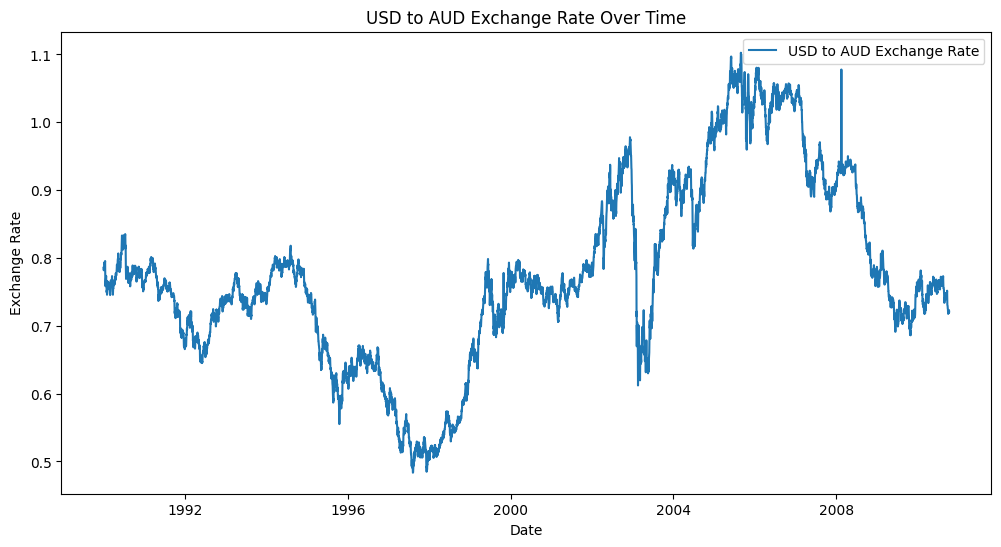

In [12]:
# Time Series Visualization
plt.figure(figsize=(12,6))
plt.plot(df, label='USD to AUD Exchange Rate')
plt.title("USD to AUD Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

In [13]:
df.isnull().sum()

Ex_rate    0
dtype: int64

In [15]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 4.2 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 4.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.6 MB 3.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 3.7 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.6 MB 4.4 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.6 MB 4.5 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 4.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 4.6 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 4.3 MB/s  0:00:02

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 

# ARIMA Model

In [16]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df.iloc[:,0])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807381528
p-value: 0.4492327353597901


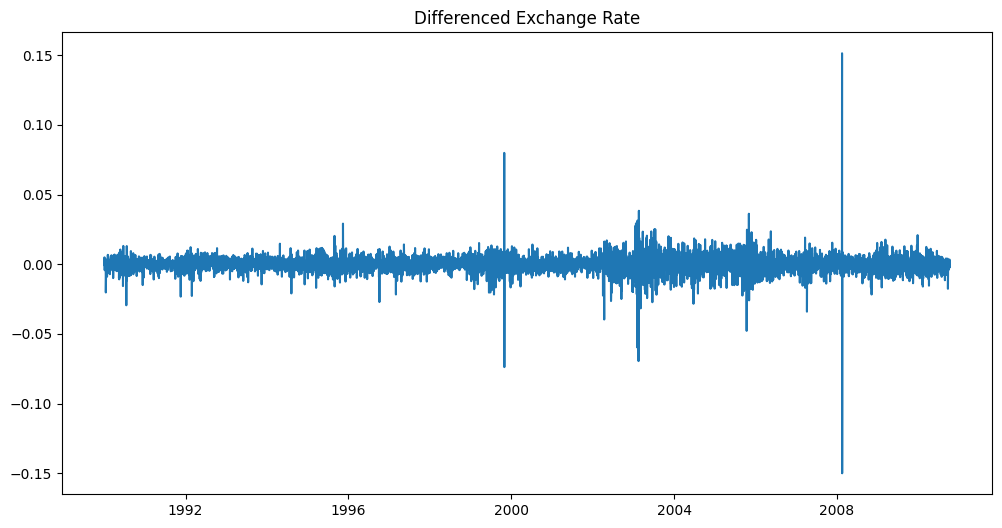

In [17]:
df_diff = df.diff().dropna()

# Plot differenced series
plt.figure(figsize=(12,6))
plt.plot(df_diff)
plt.title("Differenced Exchange Rate")
plt.show()

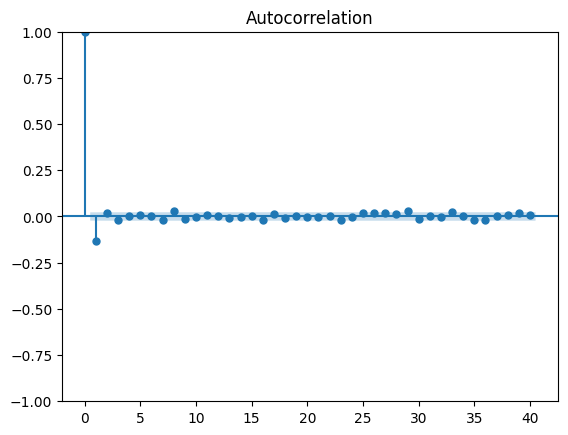

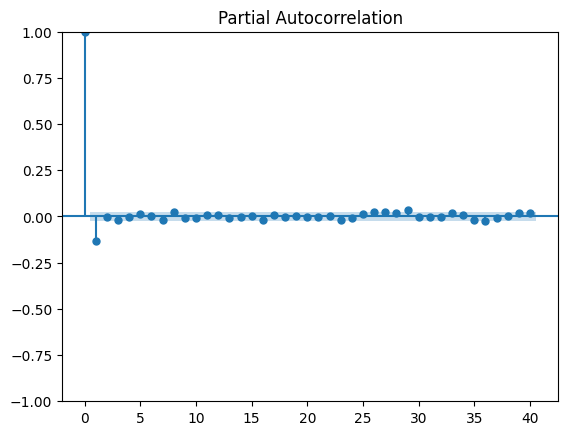

In [18]:
# ACF and PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff, lags=40)
plt.show()

plot_pacf(df_diff, lags=40)
plt.show()

In [21]:
# Train-Test Split
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [22]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1,1,1))
arima_result = arima_model.fit()

C:\Users\Yashwant\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Yashwant\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Yashwant\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [23]:
arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sat, 10 Jan 2026   AIC                         -45432.092
Time:                        11:24:03   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.000    3.24e-05    3.32e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            101358.99
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               3.83   Skew:                            -0.70
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

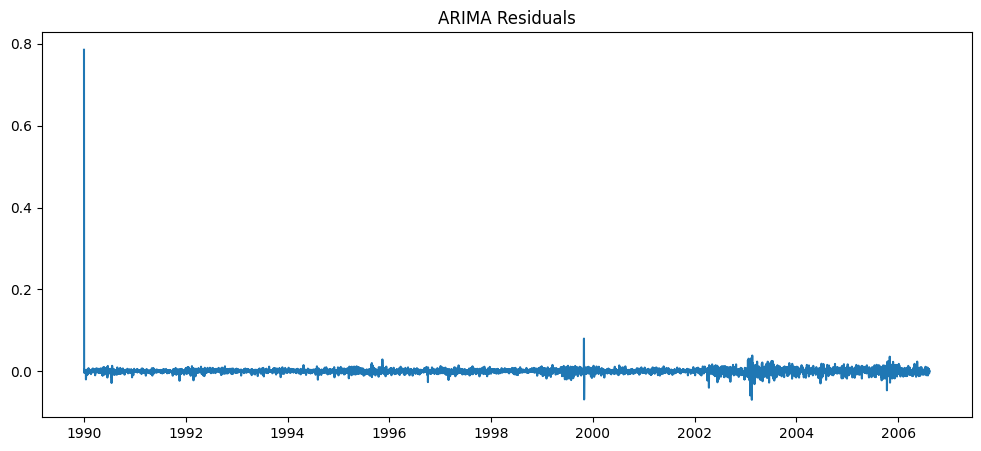

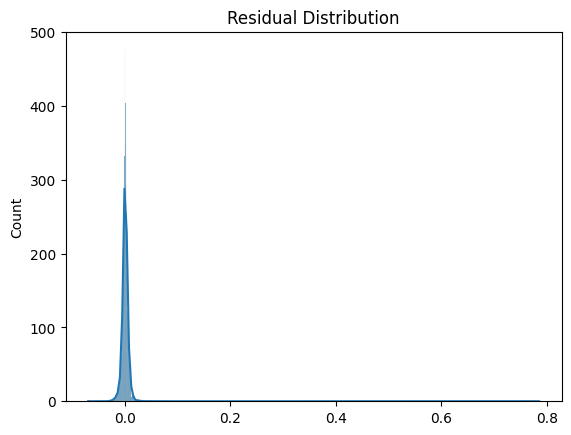

In [24]:
residuals = arima_result.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

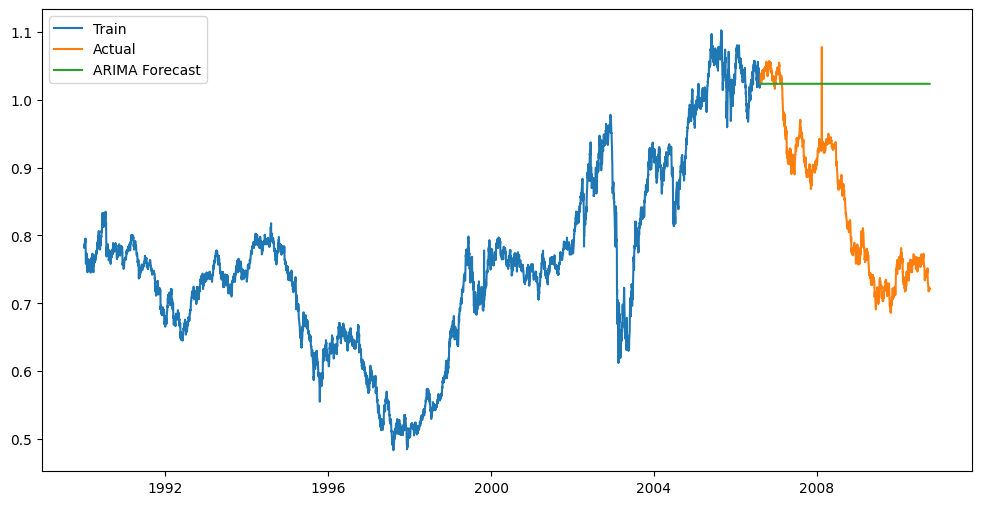

In [25]:
forecast_arima = arima_result.forecast(steps=len(test))

plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast_arima, label="ARIMA Forecast")
plt.legend()
plt.show()

# Exponential Smoothing (Holt’s Method)

In [26]:
# Model Fitting
from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

exp_result = exp_model.fit()

C:\Users\Yashwant\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


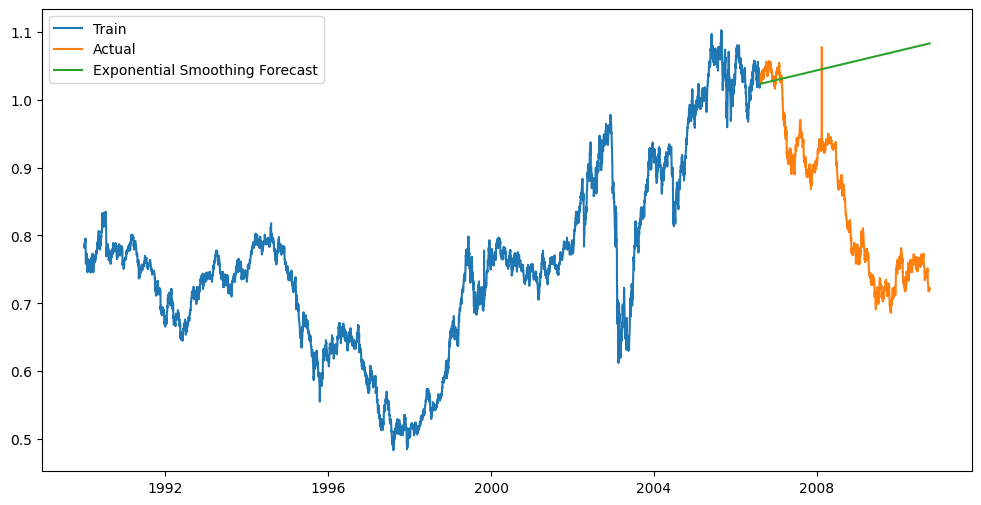

In [28]:
# Forecasting
forecast_exp = exp_result.forecast(len(test))

plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast_exp, label="Exponential Smoothing Forecast")
plt.legend()
plt.show()

# Evaluation & Comparison

In [31]:
y_true = test.iloc[:, 0].values.flatten()
y_pred = np.array(forecast_arima).flatten()

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape
arima_mae, arima_rmse, arima_mape = evaluate_model(test.values, forecast_arima)
exp_mae, exp_rmse, exp_mape = evaluate_model(test.values, forecast_exp)

results = pd.DataFrame({
    "Model": ["ARIMA", "Exponential Smoothing"],
    "MAE": [arima_mae, exp_mae],
    "RMSE": [arima_rmse, exp_rmse],
    "MAPE (%)": [arima_mape, exp_mape]
})

results

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664
